In [1]:
# Импорт библиотек, потребующихся при работе.

import pandas as pd                        # Работа с таблицами
import numpy as np                         # Вычисления и массивы
import matplotlib.pyplot as plt            # Построение графиков
import datetime as dt                      # Операции с датами
import scipy.stats as stats                # Статистические тесты: ttest_ind, mannwhitneyu, shapiro, chi2_contingency и др.
from IPython.display import display, HTML  # Вывод данных в формате HTML (таблицы рядом, стилизация)


In [2]:
# Настройка формата отображения.
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
# Загружаем датафрейм с гипофизами.
try:
    data_users = pd.read_csv('/datasets/hypothesis.csv')
    print("Файл успешно загружен.")
except:
    print("Файл НЕ загружен.")

Файл успешно загружен.


In [5]:
# Смотрим общую структуру таблицы
print(data_users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes
None


In [6]:
# Посмотрим на данные.
data_users.sample(n=9)

,Hypothesis,Reach,Impact,Confidence,Efforts
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
1,"Запустить собственную службу доставки, что сок...",2,5,4,10


In [7]:
# Приведем название колонок к нижнему регистру для простоты дальнейшей работы.
data_users.columns = data_users.columns.str.lower()

###  Приоритизация гипотез.

In [8]:
#Отключаем обрезание текста в ячейках таблицы.
pd.options.display.max_colwidth = 200

In [9]:
# Произведем расчет приоритетов гипотез по фреймворку ICE.
data_users['ICE'] = ( data_users['impact'] * data_users['confidence'])/data_users['efforts']

In [10]:
print("Получившаяся таблица приоритетов:")
print(data_users.sort_values('ICE', ascending=False)[['hypothesis', 'ICE']].to_string(index=False))

Получившаяся таблица приоритетов:
                                                                                                  hypothesis   ICE
                                                     Запустить акцию, дающую скидку на товар в день рождения 16.20
          Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей 13.33
            Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок 11.20
        Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию  8.00
Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа  7.00
                                   Запустить собственную службу доставки, что сократит срок доставки заказов  2.00
                    Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов  1.33
         Изменить структура категорий, что уве

In [11]:
# Произведем расчет приоритетов гипотез по фреймворку RICE .
data_users['RICE'] = (data_users['reach'] * data_users['impact'] * data_users['confidence'])/data_users['efforts']

In [12]:
print("Получившаяся таблица приоритетов:")
print(data_users.sort_values('RICE', ascending=False)[['hypothesis', 'RICE']].to_string(index=False))

Получившаяся таблица приоритетов:
                                                                                                  hypothesis   RICE
            Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок 112.00
Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа  56.00
          Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей  40.00
        Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию  40.00
                                                     Запустить акцию, дающую скидку на товар в день рождения  16.20
         Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар   9.00
                                   Запустить собственную службу доставки, что сократит срок доставки заказов   4.00
                    Добавить страницу 

Промежуточный вывод:
### Сравнение приоритетов гипотез по фреймворкам ICE и RICE

**Приоритет по ICE:**
1. Запустить акцию, дающую скидку на товар в день рождения
2. Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
3. Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

**Приоритет по RICE:**
1. Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок
2. Добавить блоки рекомендаций товаров на сайт интернет-магазина, чтобы повысить конверсию и средний чек заказа
3. Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

**Общие гипотезы в топ-3 обоих фреймворков:**
- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок
- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

**Причина различий:**
Разница в результатах между ICE и RICE обусловлена наличием в RICE дополнительного параметра **Reach**, который оценивает охват пользователей, затрагиваемых изменением. Учет масштаба аудитории меняет итоговую приоритизацию гипотез.

###  Анализ A/B-теста

In [13]:
# Загружаем датафреймы.
try:
    data_orders = pd.read_csv('/datasets/orders.csv')
    print("Файл успешно загружен.")
except:
    print("Файл НЕ загружен.")


Файл успешно загружен.


In [14]:
try:
    data_visitors = pd.read_csv('/datasets/visitors.csv')
    print("Файл успешно загружен.")
except:
    print("Файл НЕ загружен.")


Файл успешно загружен.


In [15]:
# Посмотрим на структуру таблиц.
print(data_orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB
None


In [16]:
print(data_visitors.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None


In [17]:
# Приведем название столбцов к нижнему регистру.
data_orders.columns = data_orders.columns.str.lower()
data_visitors.columns = data_visitors.columns.str.lower()

In [18]:
# Приведем столбец с датой в обоих таблицах к типу данных «дата».
data_orders['date'] = data_orders['date'].map( lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

In [19]:
data_visitors['date'] = data_visitors['date'].map( lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))

In [20]:
# Посмотрим на данные в таблицах.
data_orders.sample(n=10)

,transactionid,visitorid,date,revenue,group
477,2939332152,3245907439,2019-08-24,19280,B
229,4139571321,737242975,2019-08-18,15850,A
889,3586326620,1630618580,2019-08-05,450,B
300,630178370,2845785181,2019-08-18,2342,A
1145,3768600702,3320079367,2019-08-13,4900,B
1143,3551685910,2397025226,2019-08-13,910,B
677,2348589867,1294878855,2019-08-09,27390,A
672,3667885894,1230306981,2019-08-09,6613,A
737,1061639574,2195309755,2019-08-09,2960,B
181,1532499979,2617784228,2019-08-23,3468,B


In [21]:
data_visitors.sample(n=10)

,date,group,visitors
58,2019-08-28,B,654
55,2019-08-25,B,679
20,2019-08-21,A,646
41,2019-08-11,B,721
53,2019-08-23,B,546
4,2019-08-05,A,756
25,2019-08-26,A,722
18,2019-08-19,A,502
11,2019-08-12,A,595
26,2019-08-27,A,711


In [22]:
# Проведем проверку на подобии АА-тестирования с целью понять, какие данные были собраны в таблицу data_orders.
# Для этого разделим таблицу data_orders по категориям

group_A = data_orders.query("group == 'A'")
group_B = data_orders.query("group == 'B'")

In [23]:
# Найдем длительность проводимого теста.
print('Длительность теста в днях составила:',len(data_orders['date'].unique()))

Длительность теста в днях составила: 31


In [24]:
# Статистика по выручке группы A
group_A['revenue'].describe()

,revenue
count,557.00
mean,7333.58
std,11847.55
min,50.00
25%,1188.00
50%,3000.00
75%,8280.00
max,93940.00


In [25]:
# Статистика по выручке группы B
group_B['revenue'].describe()

,revenue
count,640.00
mean,9230.88
std,52449.77
min,50.00
25%,1312.50
50%,2965.00
75%,8355.25
max,1294500.00


Наблюдение:
Статистические данные показывают, что у обеих групп есть очень высокие максимальные значения. При этом значения (25%, 50%, 75%) схожи.

In [26]:
# Пересечем эти массивы групп A и B с целью понять, есть ли пользователи, попавшие в обе группы.
data_orders_mistake = np.intersect1d(group_A['visitorid'],group_B['visitorid'])
print('ID пользователей, попавшие в обе группы.\n',data_orders_mistake)

ID пользователей, попавшие в обе группы.
 [   8300375  199603092  232979603  237748145  276558944  351125977
  393266494  457167155  471551937  477780734  818047933  963407295
 1230306981 1294878855 1316129916 1333886533 1404934699 1602967004
 1614305549 1648269707 1668030113 1738359350 1801183820 1959144690
 2038680547 2044997962 2378935119 2458001652 2579882178 2587333274
 2600415354 2654030115 2686716486 2712142231 2716752286 2780786433
 2927087541 2949041841 2954449915 3062433592 3202540741 3234906277
 3656415546 3717692402 3766097110 3803269165 3891541246 3941795274
 3951559397 3957174400 3963646447 3972127743 3984495233 4069496402
 4120364173 4186807279 4256040402 4266935830]


Как ни странно, такие пользователи есть, хотя такого не должно быть, деление на группы предполагает однозначность принадлежности пользователя к одной или другой группе.

In [27]:
#  Отберем из таблицы data_orders строки с ID пользователей, вошедшие в обе группы.
data_orders_temporary = data_orders.query('visitorid in @data_orders_mistake')
print('Таблица пользователей, попавшие в обе группы.\n', data_orders_temporary)

Таблица пользователей, попавшие в обе группы.
       transactionid   visitorid       date  revenue group
2        2961555356  4069496402 2019-08-15      400     A
20       2904772834   963407295 2019-08-15      300     B
23       4252514150   351125977 2019-08-15    15185     B
24       1162046357  3234906277 2019-08-15     7555     B
26       2223239646   199603092 2019-08-15     3488     A
...             ...         ...        ...      ...   ...
1182     2682156369  1668030113 2019-08-14     1290     B
1183     1458356232   963407295 2019-08-14     4940     A
1184     1329499668  2949041841 2019-08-14    10380     B
1189     4082620617   393266494 2019-08-14    31550     B
1195     1947021204  1614305549 2019-08-14      100     A

[181 rows x 5 columns]


В исходной таблице data_orders содержится 181 запись о покупках пользователей из таблицы data_orders_temporary.
По причине невозможности как-то их рассортировать, принимаем решение удалить их, чтобы в последующем эти данные не повлияли на результат тестирования.

In [28]:
# Удалим данные и перезапишем таблицу data_orders.
data_orders = data_orders[~data_orders.isin(data_orders_temporary)].dropna().reset_index(drop=True)

In [29]:
# Посмотрим на структуры таблицы после удаления.
print(data_orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionid  1016 non-null   float64       
 1   visitorid      1016 non-null   float64       
 2   date           1016 non-null   datetime64[ns]
 3   revenue        1016 non-null   float64       
 4   group          1016 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 39.8+ KB
None


Удаление прошло корректно, можно двигаться дальше.

### Построим график кумулятивной выручки по группам.

In [30]:
# Посмотрим на исходные данные.
def df_to_html_compact(df, name):
    shape_info = f"Размер: {df.shape[0]} строк, {df.shape[1]} колонок"
    return f"<b>{name}</b><br><small>{shape_info}</small><br>{df.head().to_html()}"

display(HTML(f"""
<div style="display: flex;">
    <div style="margin-right: 20px;">{df_to_html_compact(data_visitors, 'data_visitors')}</div>
    <div>{df_to_html_compact(data_orders, 'data_orders')}</div>
</div>
"""))

In [31]:
# создаем массив уникальных пар значений дат и групп теста.
datesGroups = data_orders[['date','group']].drop_duplicates()

In [32]:
# получаем агрегированные кумулятивные по дням данные о заказах
ordersAggregated = datesGroups.apply(
    lambda x: data_orders[
        np.logical_and(
            data_orders['date'] <= x['date'], data_orders['group'] == x['group']
        )
    ].agg(
        {
            'date': 'max',
            'group': 'max',
            'transactionid': 'nunique',
            'visitorid': 'nunique',
            'revenue': 'sum',
        }
    ),
    axis=1,
).sort_values(by=['date', 'group'])


In [33]:
# получаем агрегированные кумулятивные по дням данные о посетителях
visitorsAggregated = datesGroups.apply(
    lambda x: data_visitors[
        np.logical_and(
            data_visitors['date'] <= x['date'], data_visitors['group'] == x['group']
        )
    ].agg({'date': 'max', 'group': 'max', 'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])


In [34]:
# объединяем кумулятивные данные в одной таблице и присваиваем ее столбцам понятные названия
cumulativeData = ordersAggregated.merge(
    visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulativeData.columns = [
    'date',
    'group',
    'orders',
    'buyers',
    'revenue',
    'visitors',
]

In [35]:
# Посмотрим на получившуюся таблицу.
display(HTML(f"<h4>Таблица кумулятивных данных</h4>{cumulativeData.head(5).to_html()}"))

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779.00,719
1,2019-08-01,B,17,17,59758.00,713
2,2019-08-02,A,42,36,234381.00,1338
3,2019-08-02,B,40,39,221801.00,1294
4,2019-08-03,A,66,60,346854.00,1845


In [36]:
# Таблица с данными о суммарном числе заказов и общей выручке по дням для группы А.
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]

# Таблица с накопленным числом заказов и суммарным выручке в день по группе B.
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

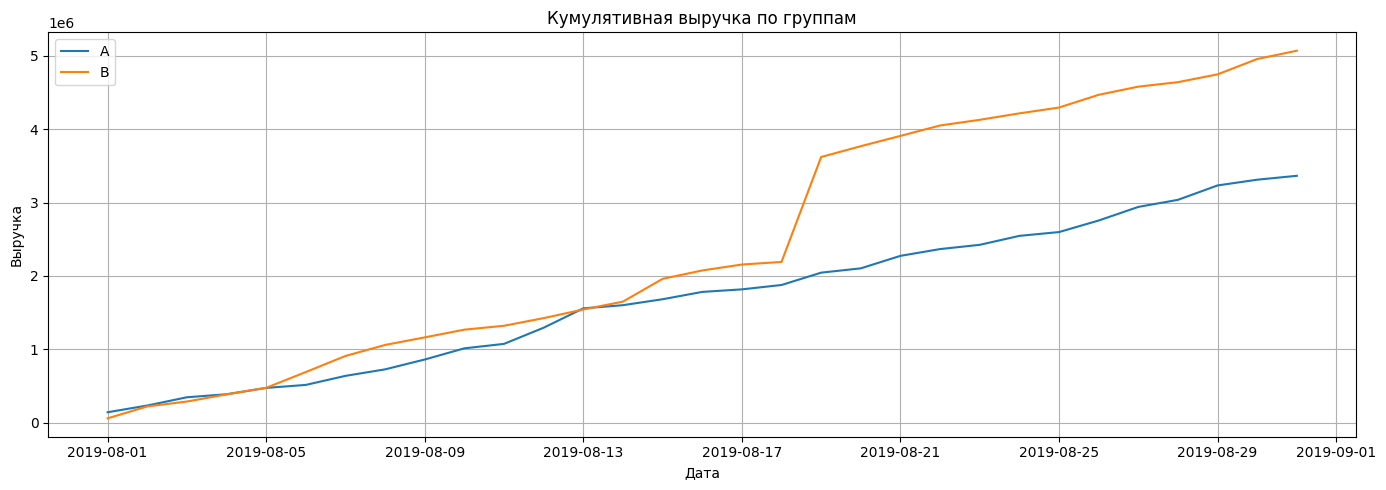

In [37]:
plt.figure(figsize=(14, 5))

# Строим график выручки группы А
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')

plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.title('Кумулятивная выручка по группам')

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

Анализ графика позволяет сделать следующие заключения: совокупный доход стабильно растёт на протяжении всего периода тестирования. После 17 августа в группе B происходит резкий скачок, который может быть вызван как увеличением числа клиентов, так и ростом среднего чека по заказам.

### Построим график кумулятивного среднего чека по группам.

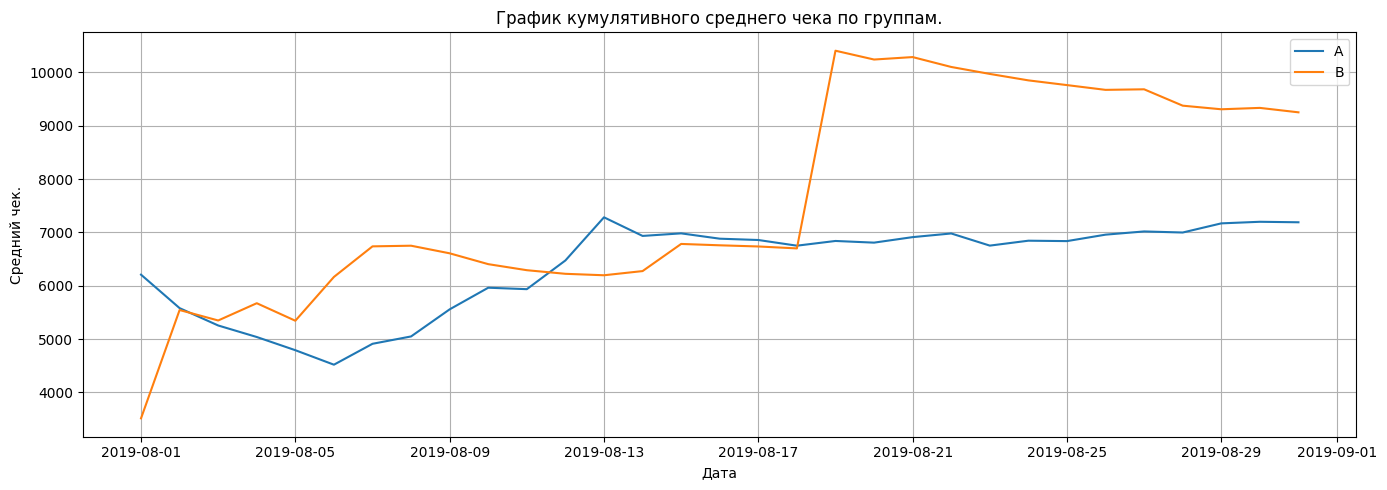

In [38]:
plt.figure(figsize=(14, 5))

plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')


plt.xlabel('Дата')
plt.ylabel('Средний чек.')
plt.title('График кумулятивного среднего чека по группам.')

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

Анализ данных по графику позволяет сделать следующие выводы:

В группе A средний чек в начале периода был ниже, но затем постепенно увеличивался и стабилизировался к 13 августа.

В группе B средний чек демонстрировал неравномерный рост до 18 числа, после чего произошло резкое увеличение, а затем — плавное снижение. Это может указывать на то, что в группу 18 числа попали нетипичные покупки.

### Построим график относительного изменения кумулятивного среднего чека группы B к группе A.

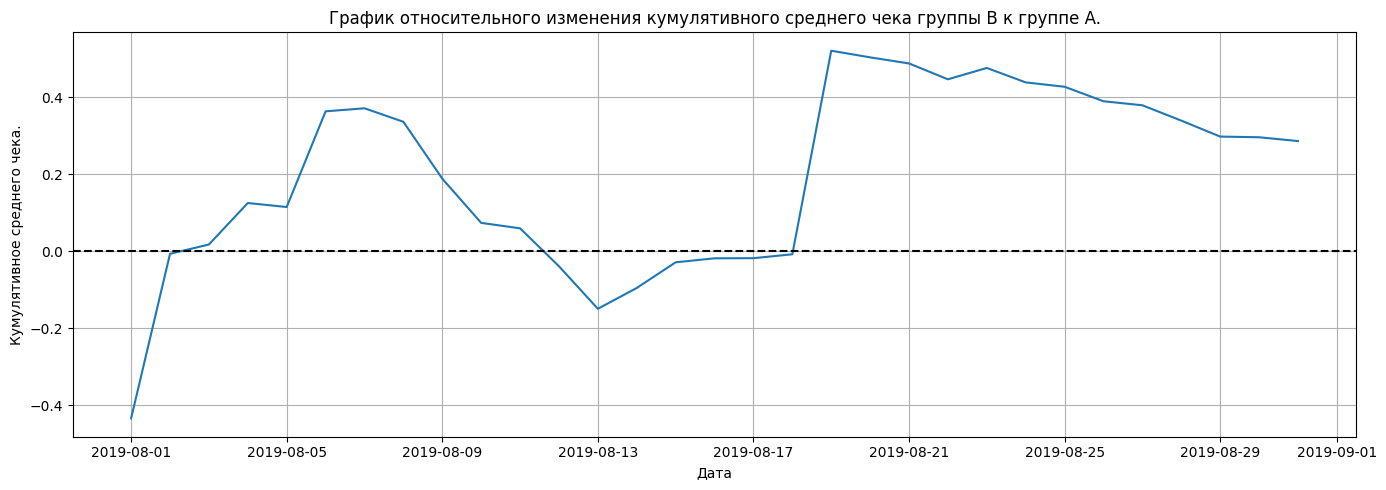

In [39]:
# собираем данные в одном датафрейме
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])

# cтроим отношение средних чеков
plt.figure(figsize=(14, 5))

plt.plot(
    mergedCumulativeRevenue['date'],
    (mergedCumulativeRevenue['revenueB'] / mergedCumulativeRevenue['ordersB']) /
    (mergedCumulativeRevenue['revenueA'] / mergedCumulativeRevenue['ordersA']) - 1
)


plt.xlabel('Дата')
plt.ylabel('Кумулятивное среднего чека.')
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A.')

plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.tight_layout()

plt.show()


На графике по-прежнему наблюдается скачок, который произошёл примерно 18 августа. Вероятно, в это время был выполнен крупный заказ.

### Построим график кумулятивного среднего количества заказов на посетителя по группам. Сделайте выводы и предположения.

In [40]:
# считаем среднее количество заказов на посетителя
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

In [41]:
# отделяем данные по группе A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# отделяем данные по группе B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']

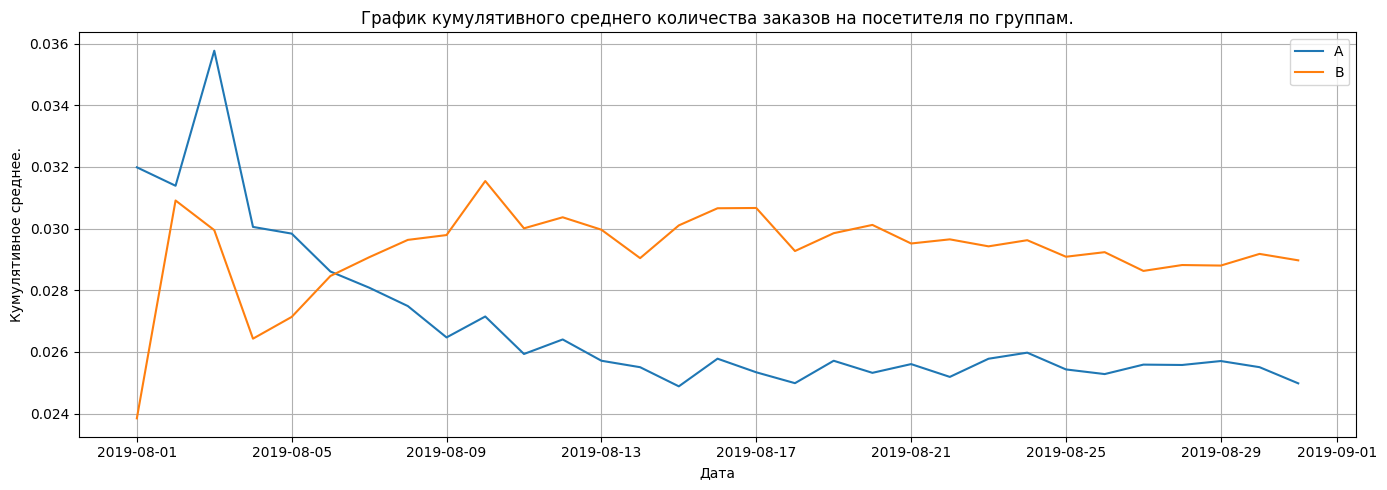

In [42]:
# строим графики

plt.figure(figsize=(14, 5))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')

plt.xlabel('Дата')
plt.ylabel('Кумулятивное среднее.')
plt.title('График кумулятивного среднего количества заказов на посетителя по группам.')

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

Исходные позиции у групп были очень разные, но затем группа А начала постепенно терять позиции, в то время как группа Б сохраняла стабильность, причём стабильно опережая группу А.

### Постройте график относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Сделайте выводы и предположения.

In [43]:
# Обьеденим таблицы
mergedCumulativeConversions = cumulativeDataA[['date', 'conversion']].merge(
    cumulativeDataB[['date', 'conversion']],
    left_on='date',
    right_on='date',
    how='left',
    suffixes=['A', 'B']
)

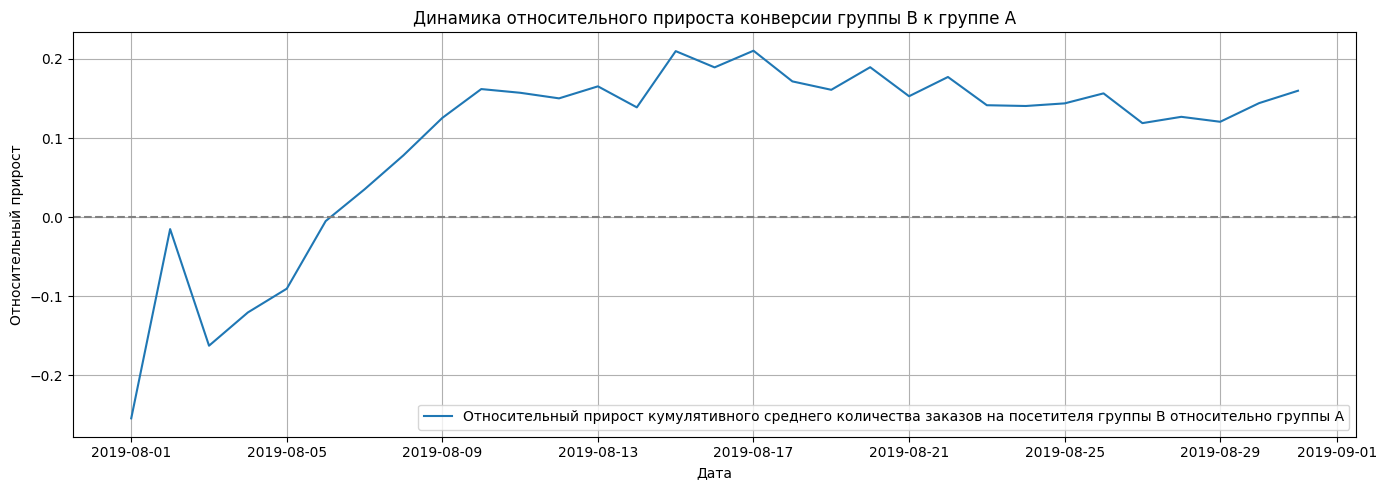

In [44]:
# строим графики
plt.figure(figsize=(14, 5))
plt.plot(
    mergedCumulativeConversions['date'],
    mergedCumulativeConversions['conversionB'] / mergedCumulativeConversions['conversionA'] - 1,
    label="Относительный прирост кумулятивного среднего количества заказов на посетителя группы B относительно группы A"
)

plt.xlabel("Дата")
plt.ylabel("Относительный прирост")
plt.title("Динамика относительного прироста конверсии группы B к группе A")
plt.axhline(y=0, color='gray', linestyle='--')  # горизонтальная линия на уровне 0
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

В целом, показатели конверсий стали более стабильными, но группа A показывает худшие результаты по сравнению с группой B на протяжении почти всего периода тестирования.

### Постройте точечный график количества заказов по пользователям.

In [45]:
# Группируем данные и производим подсчет количества заказов.
orders_per_user = data_orders.groupby('visitorid')['transactionid'].nunique().reset_index()
orders_per_user.columns = ['visitorid', 'orders']

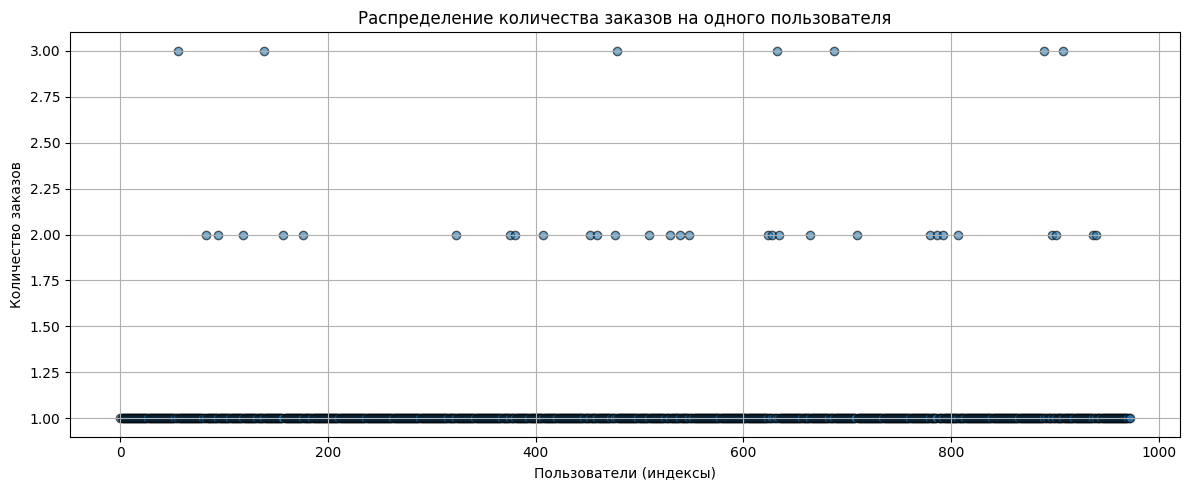

In [46]:
# Подготовка X-координат для точек
x_values = pd.Series(range(0,len(orders_per_user)))

plt.figure(figsize=(12, 5))
plt.scatter(
    x_values,
    orders_per_user['orders'],
    alpha=0.6,
    edgecolors='black'
)
plt.title('Распределение количества заказов на одного пользователя')
plt.xlabel('Пользователи (индексы)')
plt.ylabel('Количество заказов')
plt.grid(True)
plt.tight_layout()

plt.show()

Большинство клиентов оформили по одной покупке, примерно 30 человек сделали два заказа, а семь — три.

### Посчитаем 95-й и 99-й перцентили количества заказов на пользователя.

In [47]:
print(np.percentile(orders_per_user['orders'], [ 95, 99]))

[1. 2.]


Один процент пользователей сделали более двух заказов. Следует отсекать как аномальных клиентов с  более 2 покупками.

### Построим точечный график стоимостей заказов.

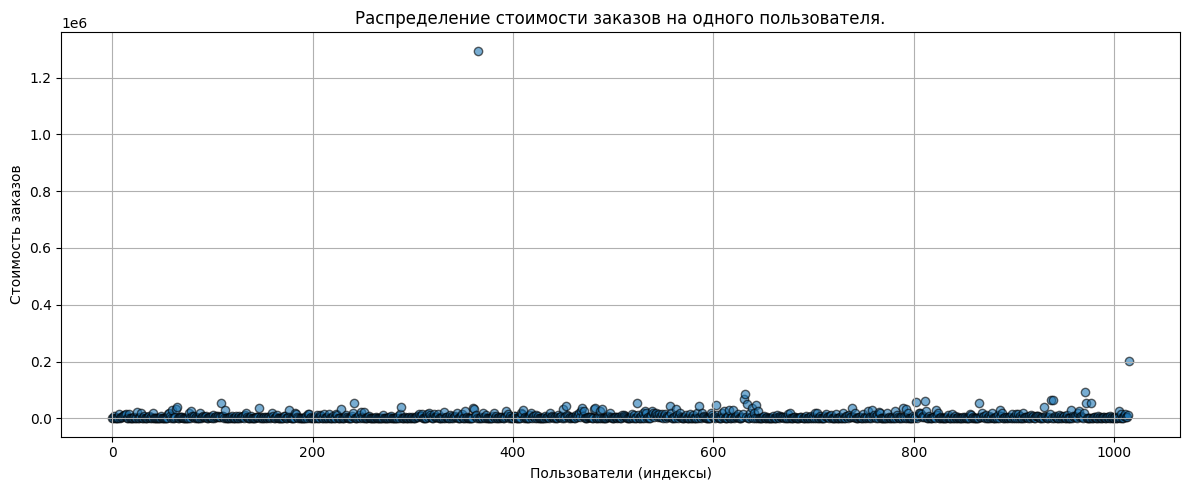

In [48]:
# Подготовка X-координат для точек
x_values = pd.Series(range(0,len(data_orders)))

plt.figure(figsize=(12, 5))
plt.scatter(
    x_values,
    data_orders['revenue'],
    alpha=0.6,
    edgecolors='black'
)
plt.title('Распределение стоимости заказов на одного пользователя.')
plt.xlabel('Пользователи (индексы)')
plt.ylabel('Стоимость заказов')
plt.grid(True)
plt.tight_layout()

plt.show()

В структуре стоимости можно выделить два значительных отклонения: одно в районе 200 тысяч, а другое — за 1,2 миллиона.

### Построим точечный график стоимостей заказов без дорогих заказов.

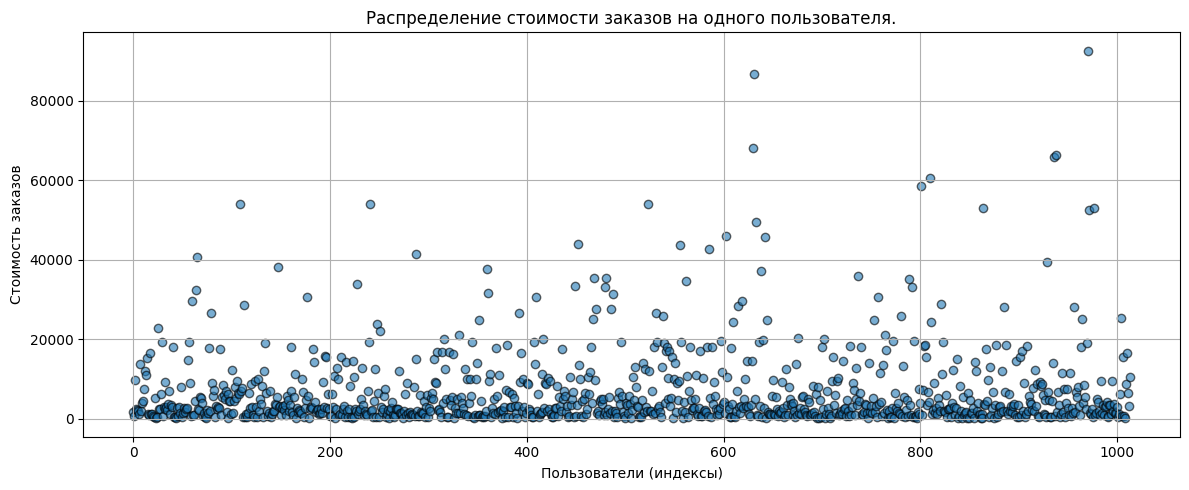

In [49]:
# Пример фильтрации данных
filtered_data = data_orders[data_orders['revenue'] < 200000]

# Подготовка X-координат для точек
x_values = pd.Series(range(0,len(filtered_data)))

plt.figure(figsize=(12, 5))
plt.scatter(
    x_values,
    filtered_data['revenue'],
    alpha=0.6,
    edgecolors='black'
)
plt.title('Распределение стоимости заказов на одного пользователя.')
plt.xlabel('Пользователи (индексы)')
plt.ylabel('Стоимость заказов')
plt.grid(True)
plt.tight_layout()

plt.show()

Основная масса заказов не превышает 3000.

### Посчитаем 95-й и 99-й перцентили стоимости заказов.

In [50]:
# Посмотрим на данные.
data_orders['revenue'].describe(percentiles=[0.05, 0.50, 0.90, 0.95, 0.99])

,revenue
count,1016.00
mean,8300.81
std,42121.99
min,50.00
5%,300.00
50%,2955.00
90%,17990.00
95%,26785.00
99%,53904.00
max,1294500.00


Пять процентов клиентов совершили покупку на сумму более 27 000 рублей. Это значение мы будем использовать в качестве критерия для исключения выбросов из выборки.

### Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Сделаем выводы и предположения.

Выдвинем предположения.

Нулевое предположение: между группами нет разницы в среднем количестве заказов на одного посетителя.

Альтернативное предположение: между группами есть разница в среднем количестве заказов на одного посетителя.

Чтобы проверить предположение о нормальности распределения данных, мы будем использовать критерий Манна–Уитни. Это связано с тем, что в данных есть выбросы, и использование других методов может исказить результаты.

In [51]:
ordersByUsersA = (
    data_orders[data_orders['group'] == 'A']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
ordersByUsersA.columns = ['userId', 'orders']

ordersByUsersB = (
    data_orders[data_orders['group'] == 'B']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
ordersByUsersB.columns = ['userId', 'orders']



sampleA = pd.concat(
    [
        ordersByUsersA['orders'],
        pd.Series(
            0,
            index=np.arange(
                data_visitors[data_visitors['group'] == 'A']['visitors'].sum()
                - len(ordersByUsersA['orders'])
            ),
            name='orders'
        )
    ],
    axis=0
)

sampleB = pd.concat(
    [
        ordersByUsersB['orders'],
        pd.Series(
            0,
            index=np.arange(
                data_visitors[data_visitors['group'] == 'B']['visitors'].sum()
                - len(ordersByUsersB['orders'])
            ),
            name='orders'
        )
    ],
    axis=0
)

print('Значение P-value:',"{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print('Относительная разница между группами:',"{0:.3f}".format(sampleB.mean() / sampleA.mean() - 1))

Значение P-value: 0.011
Относительная разница между группами: 0.160


Значение p-value меньше 0,05 свидетельствует о том, что нулевая гипотеза не подтверждается, а значит, существуют статистически значимые различия. Относительный прирост среднего значения в группе В по сравнению с группой А составляет 16%.

### Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным.

Нулевая гипотеза: различий в среднем чеке между группами нет.
Альтернативная гипотеза: различия в среднем чеке между группами есть.

In [52]:
# Статистическая значимость различий в среднем чеке между группами A и B
p_value = stats.mannwhitneyu(
    data_orders[data_orders['group'] == 'A']['revenue'],
    data_orders[data_orders['group'] == 'B']['revenue']
)[1]

# Относительное изменение среднего чека группы B по отношению к A
relative_difference = (
    data_orders[data_orders['group'] == 'B']['revenue'].mean() /
    data_orders[data_orders['group'] == 'A']['revenue'].mean()
) - 1

# Вывод результатов
print("P-value:", "{0:.3f}".format(p_value))
print("Относительное различие среднего чека группы B:", "{0:.3f}".format(relative_difference))


P-value: 0.829
Относительное различие среднего чека группы B: 0.287


Значение P-value больше 0,05 свидетельствует о том, что статистически значимых различий в средних чеках между группами не наблюдается. При этом относительный прирост среднего чека группы В по сравнению с группой А составляет 28,7%.

### Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «очищенным» данным.

In [53]:
# Подготовим данные, убрав выбросы.
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > 2]['userId'],
        ordersByUsersB[ordersByUsersB['orders'] > 2]['userId'],
    ],
    axis=0,
)

usersWithExpensiveOrders = data_orders[data_orders['revenue'] > 27000]['visitorid']

abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
print('Абсолютные потери(количество аномальных пользователей):' ,len(abnormalUsers))
print('Относительные потери:', round(len(abnormalUsers)/data_orders['visitorid'].nunique(),3))


Абсолютные потери(количество аномальных пользователей): 58
Относительные потери: 0.06


In [54]:
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['userId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data_visitors[data_visitors['group'] == 'A']['visitors'].sum()
                - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)
sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['userId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                data_visitors[data_visitors['group'] == 'B']['visitors'].sum()
                - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)
print('Значение P-value:','{0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
print('Относительная разница между группами:','{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1))

Значение P-value: 0.015
Относительная разница между группами: 0.177


Значение p-value меньше 0,05 свидетельствует о том, что нулевая гипотеза даже на очищенных данных не подтверждается, а значит, существуют статистически значимые различия. Относительный прирост среднего значения в группе В по сравнению с группой А составляет 17,7%.

### Посчитаем статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным.

In [55]:
print('Значение P-value:',
    '{0:.3f}'.format(
        stats.mannwhitneyu(
            data_orders[
                np.logical_and(
                    data_orders['group'] == 'A',
                    np.logical_not(data_orders['visitorid'].isin(abnormalUsers)),
                )
            ]['revenue'],
            data_orders[
                np.logical_and(
                    data_orders['group'] == 'B',
                    np.logical_not(data_orders['visitorid'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]
    )
)

print('Относительная разница между группами:',
    "{0:.3f}".format(
        data_orders[
            np.logical_and(
                data_orders['group'] == 'B',
                np.logical_not(data_orders['visitorid'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / data_orders[
            np.logical_and(
                data_orders['group'] == 'A',
                np.logical_not(data_orders['visitorid'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1
    )
)

Значение P-value: 0.646
Относительная разница между группами: -0.048


В среднем чеке нет разницы (как и в случае с «сырыми» данными). Однако средний чек группы B оказался на 3,4% меньше, чем средний чек группы A, хотя по «сырым» данным он составлял 28,7%. Это говорит о том, что дорогие заказы оказывали влияние на средний чекНаблюдаются статистически значимого различия по среднему количеству заказов между группами как по «сырым», так и по данным после фильтрации аномалий . Относительная разница между группами составляет 17,7% .

Нет статистически значимого различия по среднему чеку между группами ни по «сырым», ни по данным после фильтрации аномалий . При этом до очистки данных относительная разница составляла 28,7%, а после очистки составила -4,8% ..

### Результаты тестирования.

Имеющиеся факты:
Наблюдаются статистически значимого различия по среднему количеству заказов между группами как по «сырым», так и по данным после фильтрации аномалий . Относительная разница между группами составляет 17.7% .

Нет статистически значимого различия по среднему чеку между группами ни по «сырым», ни по данным после фильтрации аномалий . При этом до очистки данных относительная разница составляла 28,7%, а после очистки составила -4.8% .


График различия среднего количества заказов между группами сообщает, что результаты группы B хуже группы A и нет
значительной тенденции к улучшению:

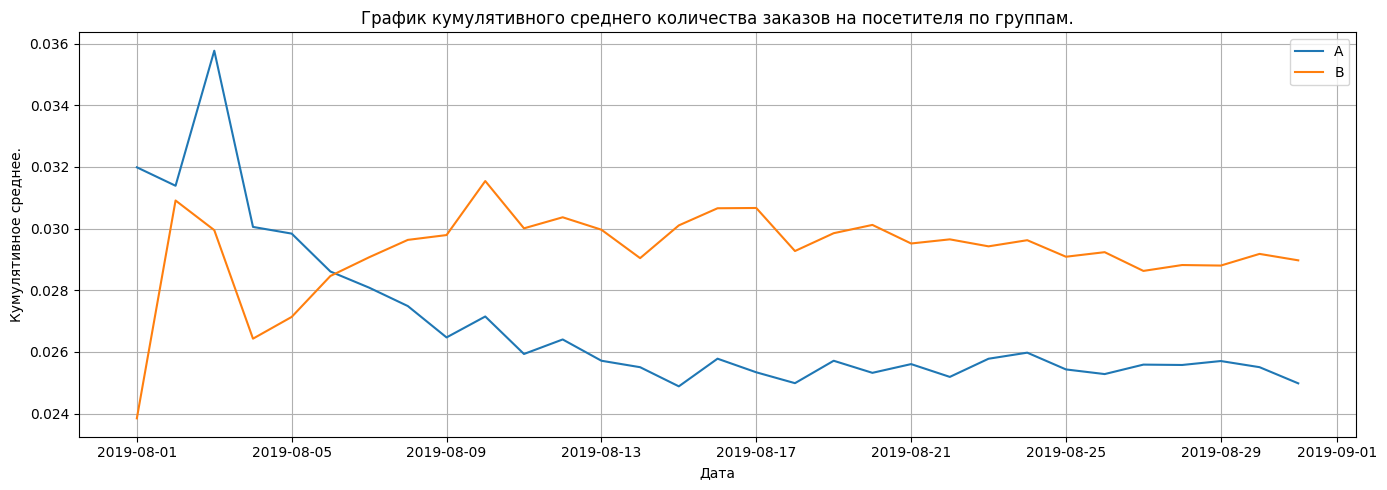

In [56]:
plt.figure(figsize=(14, 5))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')

plt.xlabel('Дата')
plt.ylabel('Кумулятивное среднее.')
plt.title('График кумулятивного среднего количества заказов на посетителя по группам.')

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

График различия среднего чека говорит о том, что результаты группы B стабилизировались и сейчас почти на 25% лучше группы А

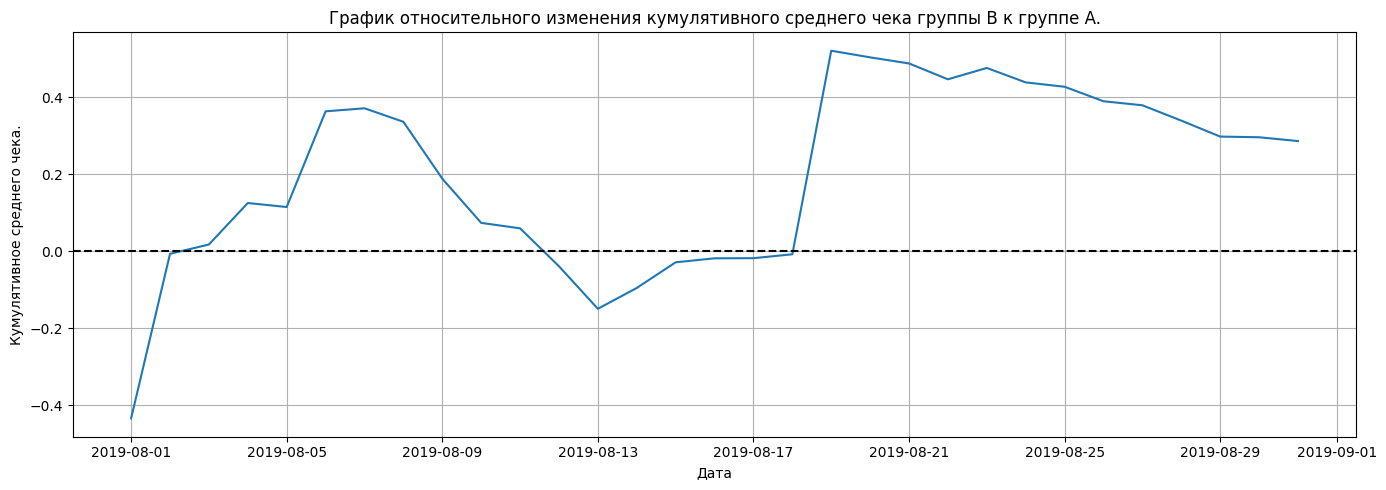

In [57]:
plt.figure(figsize=(14, 5))
plt.plot(mergedCumulativeRevenue['date'], (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])/(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1)

plt.xlabel('Дата')
plt.ylabel('Кумулятивное среднего чека.')
plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A.')

plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.tight_layout()

plt.show()

Исходя из обнаруженных фактов, тест следует остановить и признать его успешным.

Продолжать смысла нет, значения в группах стабилизировались, что при имеющихся данных сегмент B на самом деле лучше сегмента A.